# WM 2026 — Prognose-Auswertung (Backtest gegen echte Ergebnisse)

Begleit-Notebook zu *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook nimmt die **Match-Prognosen aus `wc2026_live_update.ipynb`** und
vergleicht sie **chronologisch mit den echten WM-2026-Ergebnissen**. Für jedes
bereits gespielte Spiel zeigen wir:

* **Sieg / Unentschieden / Niederlage** — welche Tendenz war getippt, und war sie **richtig**? ✓ / ✗
* **Exaktes Ergebnis** — wurde der wahrscheinlichste Spielstand (z. B. `1:0`) **getroffen**? ✓ / ✗
* **Ø Tore (λ)** — wie nah lagen die erwarteten Tore an den tatsächlich erzielten?

> **Hinweis:** Die Match-Prognosen des Live-Notebooks sind *statisch* — sie hängen
> nur an der Modell-Kalibrierung (358 historische Spiele, rein vor dem Turnier),
> nicht an WM-Ergebnissen. Der Test ist damit ein **sauberer Out-of-sample-Test**.
> Das Notebook nutzt die gespeicherten `results/*_next_matches.csv`, falls
> vorhanden, und reproduziert sie sonst mit demselben Modell.

## 1. Setup & identischer Modell-Kern wie im Live-Notebook

Dieselbe Kalibrierung (Poisson + Negative Binomial + Elo/Colley/PageRank) und
dieselben Funktionen `lam` (erwartete Tore), `wdl_consensus` (Sieg/Remis/Niederlage
aus 5 Modellen) und `modal_score` (wahrscheinlichstes exaktes Ergebnis).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import glob
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from scipy.stats import poisson as pois, nbinom
import statsmodels.api as sm
from collections import defaultdict, deque

DATA = Path("data")
NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titleweight":"bold","figure.dpi":110,
    "savefig.dpi":150,"savefig.bbox":"tight"})

GROUPS = {
    "A":["Mexico","South Africa","South Korea","Czechia"],"B":["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C":["Brazil","Morocco","Haiti","Scotland"],"D":["United States","Paraguay","Australia","Türkiye"],
    "E":["Germany","Curacao","Ivory Coast","Ecuador"],"F":["Netherlands","Japan","Sweden","Tunisia"],
    "G":["Belgium","Egypt","Iran","New Zealand"],"H":["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I":["France","Senegal","Iraq","Norway"],"J":["Argentina","Algeria","Austria","Jordan"],
    "K":["Portugal","Congo DR","Uzbekistan","Colombia"],"L":["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]
STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}
COLS = ["home_team","away_team","home_score","away_score"]
M = pd.concat([pd.read_csv(DATA/"worldcup_matches.csv")[COLS],
               pd.read_csv(DATA/"recent_internationals.csv")[COLS]], ignore_index=True)
M = M[M.home_team.isin(STRENGTH) & M.away_team.isin(STRENGTH)].copy()
M["sdiff"] = M.home_team.map(STRENGTH) - M.away_team.map(STRENGTH)
M["res"]   = np.sign(M.home_score - M.away_score).astype(int)
gl = pd.DataFrame({"goals": np.r_[M.home_score, M.away_score], "sd": np.r_[M.sdiff, -M.sdiff]})
pf = sm.GLM(gl.goals, sm.add_constant(gl[["sd"]]), family=sm.families.Poisson()).fit()
B0, B1 = pf.params["const"], pf.params["sd"]
alpha = max(1e-3, (pf.pearson_chi2/pf.df_resid - 1))
dz = sm.add_constant(pd.DataFrame({"abs": M.sdiff.abs()}))
drf = sm.GLM((M.res==0).astype(int), dz, family=sm.families.Binomial()).fit()
def pdraw(absd): return float(drf.predict(sm.add_constant(pd.DataFrame({"abs":[absd]}), has_constant="add"))[0])

def lam(a, b, R=STRENGTH): d = R[a]-R[b]; return float(np.exp(B0+B1*d)), float(np.exp(B0-B1*d))
def scoreline(a, b, R=STRENGTH, disp=0.0, maxg=7):
    la, lb = lam(a, b, R); g = np.arange(maxg+1)
    def pmf(l):
        if disp > 1e-6: rr = 1/disp; return nbinom.pmf(g, rr, rr/(rr+l))
        return pois.pmf(g, l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum(); return P
def wdl(a, b, R=STRENGTH):
    P = scoreline(a, b, R); return np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()
def modal_score(a, b):
    P = scoreline(a, b); n = P.shape[0]; i, j = divmod(int(np.argmax(P)), n); return f"{i}:{j}"

def _ratings(kind):
    teams = sorted(set(M.home_team)|set(M.away_team)); idx={t:i for i,t in enumerate(teams)}; n=len(teams)
    if kind == "colley":
        C=np.eye(n)*2; b=np.ones(n)
        for _,r in M.iterrows():
            i,j=idx[r.home_team],idx[r.away_team]; C[i,i]+=1;C[j,j]+=1;C[i,j]-=1;C[j,i]-=1
            wi=1.0 if r.res>0 else (0.5 if r.res==0 else 0.0); b[i]+=wi-0.5;b[j]+=(1-wi)-0.5
        x=np.linalg.solve(C,b); raw={t:x[idx[t]] for t in teams}
    else:
        W=np.zeros((n,n))
        for _,r in M.iterrows():
            i,j=idx[r.home_team],idx[r.away_team]
            if r.res>0:W[j,i]+=1
            elif r.res<0:W[i,j]+=1
            else:W[i,j]+=.5;W[j,i]+=.5
        cs=W.sum(1,keepdims=True);cs[cs==0]=1;T=W/cs;pr=np.ones(n)/n
        for _ in range(100): pr=0.15/n+0.85*(T.T@pr)
        raw={t:pr[idx[t]] for t in teams}
    v=np.array(list(raw.values())); mu,sd=v.mean(),v.std()+1e-9
    return {t:(1850+(raw[t]-mu)/sd*130) if t in raw else STRENGTH[t] for t in TEAMS}
COLLEY, PAGER = _ratings("colley"), _ratings("pagerank")

def wdl_consensus(a, b):
    # Mittel aus 5 Modellen (wie im Live-Notebook)
    mods = [wdl(a,b,STRENGTH)]
    P = scoreline(a,b,STRENGTH,alpha); mods.append((np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()))
    da = STRENGTH[a]-STRENGTH[b]; we = 1/(1+10**(-da/400)); pdr = pdraw(abs(da))
    mods.append(((1-pdr)*we, pdr, (1-pdr)*(1-we)))
    mods.append(wdl(a,b,COLLEY)); mods.append(wdl(a,b,PAGER))
    arr = np.array(mods).mean(0); return tuple(arr/arr.sum())
print(f"Modell-Kern bereit (kalibriert auf {len(M)} historischen Spielen).")

Modell-Kern bereit (kalibriert auf 358 historischen Spielen).


## 2. Echte Ergebnisse & gespeicherte Live-Prognosen laden

Die echten, bereits gespielten WM-Spiele kommen aus `data/wc2026_results.csv`
(mit `python refresh_data.py` aktualisierbar). Zusätzlich suchen wir die vom
Live-Notebook gespeicherten Prognose-Schnappschüsse `results/*_next_matches.csv`.

In [2]:
NAME_MAP = {"Czech Republic":"Czechia","Bosnia & Herzegovina":"Bosnia-Herzegovina","Turkey":"Türkiye",
            "USA":"United States","Curaçao":"Curacao","DR Congo":"Congo DR"}
def nm(t): return NAME_MAP.get(t, t)

res = pd.read_csv(DATA/"wc2026_results.csv")
played = res[res.score1.notna() & res.group.notna()].copy()
played["home"] = played.team1.map(nm); played["away"] = played.team2.map(nm)
played = played[played.home.isin(STRENGTH) & played.away.isin(STRENGTH)].sort_values("date").reset_index(drop=True)

# gespeicherte Live-Prognosen (statisch -> erste Fundstelle je Begegnung genügt)
saved = {}
snap_files = sorted(glob.glob("results/*_next_matches.csv"))
for f in snap_files:
    df = pd.read_csv(f)
    for _, r in df.iterrows():
        b = str(r.get("Begegnung", ""))
        if " – " not in b: continue
        h, a = [x.strip() for x in b.split(" – ")]
        if (h, a) in saved: continue
        try:
            lh, la = [float(x) for x in str(r["Ø Tore (λ)"]).split(" : ")]
            saved[(h, a)] = dict(lam_h=lh, lam_a=la, p_w=float(r["P(Sieg 1)"]),
                                 p_d=float(r["P(Remis)"]), p_l=float(r["P(Sieg 2)"]),
                                 modal=str(r["wahrsch. Erg."]))
        except Exception:
            pass
print(f"Gespielte WM-Spiele zum Auswerten: {len(played)}")
print(f"Gespeicherte Live-Prognose-Schnappschüsse: {len(snap_files)}  ->  {len(saved)} eindeutige Begegnungen")

Gespielte WM-Spiele zum Auswerten: 21
Gespeicherte Live-Prognose-Schnappschüsse: 1  ->  51 eindeutige Begegnungen


## 3. Prognose-Log: Vorhersage vs. Realität je Spiel

Für jedes gespielte Spiel holen wir die Prognose (aus dem Live-Snapshot, falls
vorhanden; sonst identisch reproduziert) und vergleichen sie mit dem echten
Endstand. `Tendenz` = die getippte Mehrheit aus Sieg/Remis/Niederlage.

In [3]:
LBL = {1:"Heimsieg", 0:"Remis", -1:"Auswärtssieg"}

def predict(home, away):
    if (home, away) in saved:
        s = saved[(home, away)]; src = "Live-Snapshot"
        return s["lam_h"], s["lam_a"], s["p_w"]/100, s["p_d"]/100, s["p_l"]/100, s["modal"], src
    lh, la = lam(home, away); w, d, l = wdl_consensus(home, away)
    return lh, la, w, d, l, modal_score(home, away), "reproduziert"

rows = []
for _, m in played.iterrows():
    h, a, gh, ga = m.home, m.away, int(m.score1), int(m.score2)
    lh, la, w, d, l, modal, src = predict(h, a)
    probs = np.array([w, d, l]); ti = int(np.argmax(probs)); tend_pred = [1,0,-1][ti]
    tend_act = int(np.sign(gh - ga))
    rows.append(dict(
        Datum=m.date, Begegnung=f"{h} – {a}", src=src,
        lam_h=lh, lam_a=la, gh=gh, ga=ga,
        lam_str=f"{lh:.1f} : {la:.1f}", endstand=f"{gh}:{ga}",
        lam_err=abs(lh-gh)+abs(la-ga),
        tipp=f"{LBL[tend_pred]} {probs[ti]*100:.0f}%",
        tend_pred=tend_pred, tend_act=tend_act, p_w=w, p_d=d, p_l=l,
        wdl_ok=(tend_pred==tend_act), modal=modal, score_ok=(modal==f"{gh}:{ga}")))
ev = pd.DataFrame(rows)
print(f"{len(ev)} Spiele ausgewertet.  Quelle der Prognosen: "
      + ", ".join(f"{k}={v}" for k, v in ev.src.value_counts().items()))

21 Spiele ausgewertet.  Quelle der Prognosen: reproduziert=21


### 3b. Chronologische Detailtabelle

In [4]:
det = pd.DataFrame({
    "Datum": ev.Datum, "Begegnung": ev.Begegnung,
    "λ-Prognose": ev.lam_str, "Endstand": ev.endstand,
    "λ-Fehler": ev.lam_err.round(2),
    "Tipp (W/U/N)": ev.tipp, "Tendenz": np.where(ev.wdl_ok, "✓", "✗"),
    "Modus-Tipp": ev.modal, "Ergebnis": np.where(ev.score_ok, "✓", "✗"),
})
def _mark(v):
    return ("background-color:#d7e9d2;color:#1b5e20;font-weight:bold" if v=="✓"
            else "background-color:#f6d4cf;color:#8a2a1f;font-weight:bold" if v=="✗" else "")
(det.style.hide(axis="index")
   .map(_mark, subset=["Tendenz","Ergebnis"])
   .background_gradient(cmap="Reds", subset=["λ-Fehler"])
   .set_caption("Prognose vs. Realität je Spiel — Tendenz ✓/✗ (Sieg/Remis/Niederlage), "
                "Ergebnis ✓/✗ (exakter Spielstand), λ = erwartete Tore"))

Datum,Begegnung,λ-Prognose,Endstand,λ-Fehler,Tipp (W/U/N),Tendenz,Modus-Tipp,Ergebnis
2026-06-11,Mexico – South Africa,1.6 : 0.9,2:0,1.290000,Heimsieg 49%,✓,1:0,✗
2026-06-11,South Korea – Czechia,1.1 : 1.2,2:1,1.100000,Auswärtssieg 38%,✗,1:1,✗
2026-06-12,Canada – Bosnia-Herzegovina,1.3 : 1.1,1:1,0.380000,Heimsieg 38%,✗,1:1,✓
2026-06-12,United States – Paraguay,1.4 : 1.0,4:1,2.670000,Heimsieg 43%,✓,1:1,✗
2026-06-13,Qatar – Switzerland,0.9 : 1.6,1:1,0.710000,Auswärtssieg 59%,✗,0:1,✗
2026-06-13,Brazil – Morocco,1.5 : 1.0,1:1,0.490000,Heimsieg 50%,✗,1:0,✗
2026-06-13,Haiti – Scotland,0.7 : 1.9,0:1,1.620000,Auswärtssieg 61%,✓,0:1,✓
2026-06-13,Australia – Türkiye,1.0 : 1.4,2:0,2.470000,Auswärtssieg 44%,✗,0:1,✗
2026-06-14,Sweden – Tunisia,1.4 : 1.0,5:1,3.590000,Heimsieg 48%,✓,1:0,✗
2026-06-14,Netherlands – Japan,1.5 : 1.0,2:2,1.580000,Heimsieg 54%,✗,1:0,✗


## 4. Vorhersagequalität — Kennzahlen

* **Tendenz-Trefferquote (WDL):** Anteil korrekt getippter Sieg/Remis/Niederlage.
* **Exakt-Ergebnis-Trefferquote:** Anteil exakt getroffener Spielstände.
* **λ-MAE:** mittlerer absoluter Fehler der erwarteten Tore (Heim + Auswärts).
* **Brier-Score** & **Log-Loss:** Güte der Wahrscheinlichkeiten (kleiner = besser).
* Zum Vergleich: **Zufall** (3 Klassen) und die Baseline **„immer Heimsieg"**.

In [5]:
n = len(ev)
oh = np.zeros((n,3)); oh[np.arange(n), [ {1:0,0:1,-1:2}[t] for t in ev.tend_act ]] = 1
P = ev[["p_w","p_d","p_l"]].values
brier = float(np.mean(np.sum((P-oh)**2, axis=1)))
logloss = float(-np.mean(np.log(np.clip(P[np.arange(n), oh.argmax(1)], 1e-6, 1))))
home_base = float((ev.tend_act==1).mean())

metrics = pd.DataFrame({
    "Kennzahl": ["Spiele ausgewertet","Tendenz-Trefferquote (WDL)","davon Zufallsniveau",
                 "Baseline „immer Heimsieg“","Exakt-Ergebnis-Trefferquote",
                 "λ-MAE Heim","λ-MAE Auswärts","λ-MAE gesamt (Heim+Ausw.)",
                 "Brier-Score (W/U/N)","Log-Loss (W/U/N)"],
    "Wert": [f"{n}", f"{ev.wdl_ok.mean()*100:.1f}%", "33.3%",
             f"{home_base*100:.1f}%", f"{ev.score_ok.mean()*100:.1f}%",
             f"{np.abs(ev.lam_h-ev.gh).mean():.2f}", f"{np.abs(ev.lam_a-ev.ga).mean():.2f}",
             f"{ev.lam_err.mean():.2f}", f"{brier:.3f}", f"{logloss:.3f}"],
})
print(f"Tendenz {ev.wdl_ok.sum()}/{n} ({ev.wdl_ok.mean()*100:.0f}%) · "
      f"exaktes Ergebnis {ev.score_ok.sum()}/{n} ({ev.score_ok.mean()*100:.0f}%)")
metrics.style.hide(axis="index").set_caption("Vorhersagequalität der Live-Prognosen am realen WM-Set")

Tendenz 9/21 (43%) · exaktes Ergebnis 2/21 (10%)


Kennzahl,Wert
Spiele ausgewertet,21
Tendenz-Trefferquote (WDL),42.9%
davon Zufallsniveau,33.3%
Baseline „immer Heimsieg“,47.6%
Exakt-Ergebnis-Trefferquote,9.5%
λ-MAE Heim,1.15
λ-MAE Auswärts,0.63
λ-MAE gesamt (Heim+Ausw.),1.78
Brier-Score (W/U/N),0.646
Log-Loss (W/U/N),1.046


## 5. Visualisierung der Vorhersagequalität

(1) kumulative Tendenz-Trefferquote über die Zeit · (2) erwartete λ vs. echte
Tore · (3) Tendenz-Konfusionsmatrix · (4) Kalibrierung (Ø-Prognose vs.
beobachtete Häufigkeit je Ausgang).

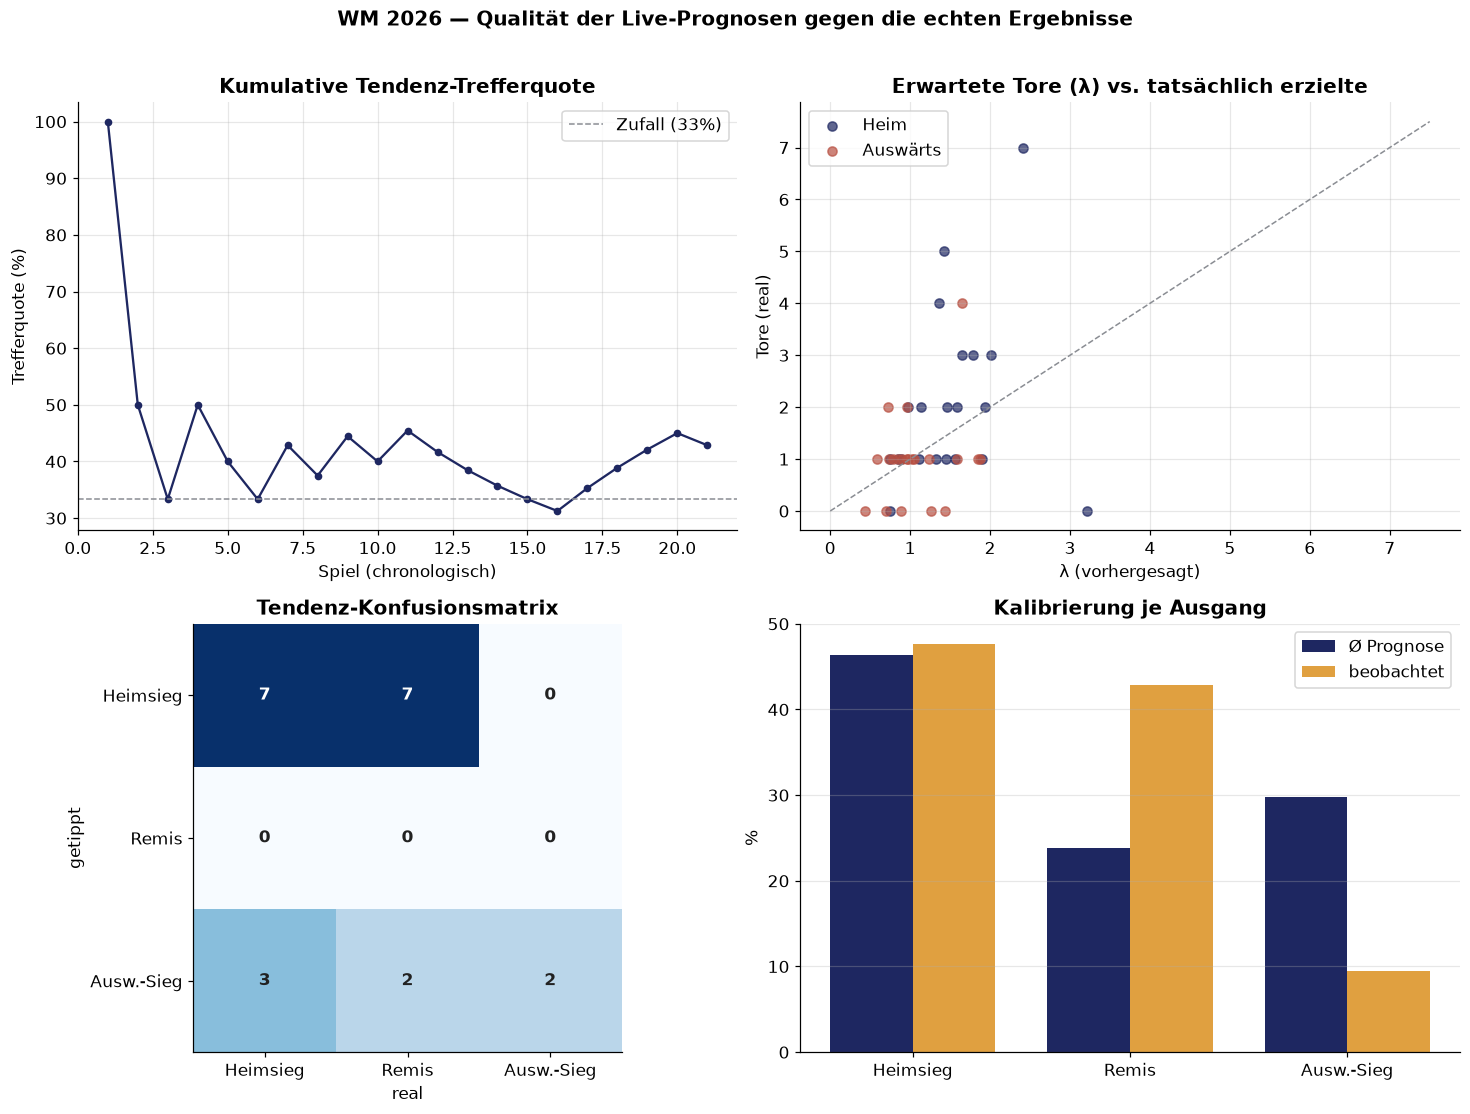

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(13.5, 10))

# (1) kumulative Trefferquote
cum = ev.wdl_ok.expanding().mean().values*100
ax[0,0].plot(range(1,n+1), cum, "-o", color=NAVY, ms=4)
ax[0,0].axhline(100/3, color=GREY, ls="--", lw=1, label="Zufall (33%)")
ax[0,0].set_title("Kumulative Tendenz-Trefferquote"); ax[0,0].set_xlabel("Spiel (chronologisch)")
ax[0,0].set_ylabel("Trefferquote (%)"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# (2) lambda vs echte Tore
ax[0,1].scatter(ev.lam_h, ev.gh, color=NAVY, label="Heim", alpha=.7)
ax[0,1].scatter(ev.lam_a, ev.ga, color=RED, label="Auswärts", alpha=.7)
mx = max(ev.gh.max(), ev.ga.max(), 4)+0.5
ax[0,1].plot([0,mx],[0,mx], color=GREY, ls="--", lw=1)
ax[0,1].set_title("Erwartete Tore (λ) vs. tatsächlich erzielte")
ax[0,1].set_xlabel("λ (vorhergesagt)"); ax[0,1].set_ylabel("Tore (real)"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)

# (3) Konfusionsmatrix Tendenz
order=[1,0,-1]; lab=["Heimsieg","Remis","Ausw.-Sieg"]
cm=np.zeros((3,3),int)
for tp,ta in zip(ev.tend_pred, ev.tend_act): cm[order.index(tp), order.index(ta)]+=1
im=ax[1,0].imshow(cm, cmap="Blues")
ax[1,0].set_xticks(range(3)); ax[1,0].set_xticklabels(lab); ax[1,0].set_yticks(range(3)); ax[1,0].set_yticklabels(lab)
ax[1,0].set_xlabel("real"); ax[1,0].set_ylabel("getippt"); ax[1,0].set_title("Tendenz-Konfusionsmatrix")
for i in range(3):
    for j in range(3): ax[1,0].text(j,i,cm[i,j],ha="center",va="center",
                                    color="white" if cm[i,j]>cm.max()*0.5 else "#222", fontweight="bold")

# (4) Kalibrierung: Ø vorhergesagte Wahrscheinlichkeit vs. beobachtete Häufigkeit
pred_avg=[ev.p_w.mean(), ev.p_d.mean(), ev.p_l.mean()]
obs_freq=[(ev.tend_act==1).mean(), (ev.tend_act==0).mean(), (ev.tend_act==-1).mean()]
x=np.arange(3); w=0.38
ax[1,1].bar(x-w/2, np.array(pred_avg)*100, w, color=NAVY, label="Ø Prognose")
ax[1,1].bar(x+w/2, np.array(obs_freq)*100, w, color=AMBER, label="beobachtet")
ax[1,1].set_xticks(x); ax[1,1].set_xticklabels(lab); ax[1,1].set_ylabel("%")
ax[1,1].set_title("Kalibrierung je Ausgang"); ax[1,1].legend(); ax[1,1].grid(axis="y", alpha=.3)

fig.suptitle("WM 2026 — Qualität der Live-Prognosen gegen die echten Ergebnisse",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("nb_eval_quality.png"); plt.show()

## 6. Ergebnis speichern & Fazit

In [7]:
ev_out = ev[["Datum","Begegnung","src","lam_str","endstand","lam_err","tipp",
             "wdl_ok","modal","score_ok"]].copy()
ev_out.to_csv("prediction_eval_log.csv", index=False)
print("Gespeichert: prediction_eval_log.csv")
print(f"\nFazit (Stand: {len(ev)} Spiele):")
print(f"  · Tendenz (Sieg/Remis/Niederlage) korrekt: {ev.wdl_ok.mean()*100:.0f}%  (Zufall 33%)")
print(f"  · Exaktes Ergebnis getroffen:              {ev.score_ok.mean()*100:.0f}%")
print(f"  · λ-MAE (erwartete vs. echte Tore):        {ev.lam_err.mean():.2f}")

Gespeichert: prediction_eval_log.csv

Fazit (Stand: 21 Spiele):
  · Tendenz (Sieg/Remis/Niederlage) korrekt: 43%  (Zufall 33%)
  · Exaktes Ergebnis getroffen:              10%
  · λ-MAE (erwartete vs. echte Tore):        1.78


**Einordnung.** Die ersten WM-Spiele sind ein **kleines, varianzreiches**
Set — mit etlichen Überraschungen der 1. Runde (z. B. 0:0 Spanien–Kap Verde,
2:2 Niederlande–Japan). Tendenz-Quoten knapp über/um Zufallsniveau und niedrige
Exakt-Trefferquoten sind hier normal; mit jedem weiteren Spieltag
(`python refresh_data.py`, dann dieses Notebook erneut ausführen) wird die
Auswertung aussagekräftiger. Exakte Spielstände sind generell schwer zu treffen —
selbst das wahrscheinlichste Resultat hat meist nur ~12–15 % Wahrscheinlichkeit.

*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026). Daten:
openfootball (Public Domain).*